# Métodos de Monte Carlo

En este ejercicio vamos a implementar la primera solución para los problemas de aprendizaje por refuerzo, los métodos de Monte Carlo. 

Recuerde que el método de Monte Carlo consiste en la colección de muestras calculando los valores para la secuencia completa de los estados hasta el estado final. Una vez se han coleccionado "suficientes" muestras, el valor de los estados se toma como el valor promedio de las muestras sobre las cuales apareció el estado.

Para resolver problemas de aprendizaje por refuerzo utilizando el método de Monte Carlo crearemos un archivo `mcm.py`. Inicialmente utilizaremos este archivo para solucionar el problema sobre el ambiente de Gridworld (suponiendo un ruido de `0.25` para las acciones, es decir que la probabilidad de ejecutar la acción deseada es de 0.75 y una acción aleatoria (dividida en partes iguales) con probabilidad de 0.25).

**Task 1**
1.	Implemente la classe `MCM` para solucionar Gridworld sin conocer los detalles del modelo de MDP para el problema. Es decir, en este caso, nuestro agente de `MCM` no tendrá acceso al `mdp` como era el caso para la iteración de valores o iteración de políticas.

2. El comportamiento del agente (de Monte Carlo) esta dado por dos momentos. El proceso de recolección de muestras y el proceso de explotación de las mismas, es decir, el cálculo de la política del agente. Usted debe implementar el comportamiento del agente dado que, ejecutando episodios como muestras, sea capaz de calcular los valores para los estados.

Para la implementación de `MCM` responda las siguientes preguntas. Tenga en cuenta que debe ejecutar su agente múltiples veces para poder observar el comportamiento (una sola instancia no nos puede llevar a ninguna conclución).
Justifique su respuestas con análisis de la ejejcución y gráficas del comportamiento.
1. ¿Cuantas muestras debe tomar el agente? Su implementación no debe utilizar este número como un parámetro o tenerlo como un factor predeterminado del agente.
2. ¿Cómo se comparan los valores de `MCM` con respecto a los valores obtenidos en el ejercicio de iteración de valores `value_iteration`? ¿Porqué se da la diferencia si existe alguna, o porqué no existe ninguna diferencia?   
3. ¿Cómo se compara la política obtenida utilizando `MCM` con respecto a la política obtenida en el jercicio de iteración de políticas `policy_iteration`? ¿Porqué se da la diferencia si existe alguna, o porqué no existe ninguna diferencia?
4. ¿Cuál es el efecto de del factor de descuento sobre el método de Monte Carlo, calcule la solución de Gridworld con diferentes valores?


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from environment import Environment
from mcm import MCM

np.set_printoptions(precision=4, suppress=True)

## Definición del ambiente Gridworld

In [2]:
grid_board = [
    [' ', ' ', ' ', '+1'],
    [' ', '#', ' ', '-1'],
    ['S', ' ', ' ', ' '],
]

grid_P = [
    [[0.1, 0.1, 0, 0.8],  [0.1, 0.1, 0, 0.8],  [0.1, 0.1, 0, 0.8],  [1]],
    [[0.8, 0, 0.1, 0.1],  '#',                   [0.8, 0, 0.1, 0.1],  [-1]],
    [[0.8, 0, 0.1, 0.1],  [0.1, 0.1, 0.8, 0],   [0.1, 0.1, 0.8, 0],  [0.1, 0.1, 0.8, 0]],
]

gridworld = Environment(grid_board, grid_P)
print(f"Gridworld: {gridworld.nrows}x{gridworld.ncols}, estado inicial: {gridworld.initial_state}")

# --- Utilidades de visualización ---
ACTION_ARROWS = {"up": "↑", "down": "↓", "left": "←", "right": "→", "exit": "✓", None: "·"}

def create_heatmap(matrix, title, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots()
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=matrix.min(), vmax=matrix.max())
    if standalone:
        plt.colorbar(im, ax=ax, label="Valor")
    ax.axis("off")
    for x in range(matrix.shape[0]):
        for y in range(matrix.shape[1]):
            ax.text(y, x, f"{matrix[x, y]:.3f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    if standalone:
        plt.tight_layout()
        plt.show()

def values_to_matrix(values, env):
    m = np.zeros((env.nrows, env.ncols))
    for (x, y), v in values.items():
        m[x, y] = v
    return m

def policy_to_matrix(get_policy_fn, env):
    m = np.empty((env.nrows, env.ncols), dtype=object)
    for i in range(env.nrows):
        for j in range(env.ncols):
            state = (i, j)
            cell = env.board[i][j]
            if cell == env.PROHIBITED_CELL:
                m[i, j] = "█"
            else:
                m[i, j] = ACTION_ARROWS.get(get_policy_fn(state), "·")
    return m

def show_policy(get_policy_fn, env, title):
    mat = policy_to_matrix(get_policy_fn, env)
    print(f"\n{title}")
    for row in mat:
        print("  " + "  ".join(row))


Gridworld: 3x4, estado inicial: (2, 0)


## 1. ¿Cuántas muestras debe tomar el agente?

El agente **no** recibe un número fijo de episodios. La clase `MCM` determina
la convergencia de manera adaptativa: cada `window` episodios se compara el
cambio máximo en los valores (`max_delta`). Si ese cambio es menor que
`convergence_threshold` durante `patience` ventanas consecutivas, el agente
se detiene.

A continuación se corre el agente **10 veces** y se registra cuántos episodios
necesitó, junto con la curva de cambio a lo largo del tiempo.


Ejecutando MCM 10 veces para analizar convergencia...

  Run  1: 50000 episodios
  Run  2: 50000 episodios
  Run  3: 50000 episodios
  Run  4: 50000 episodios
  Run  5: 50000 episodios
  Run  6: 50000 episodios
  Run  7: 50000 episodios
  Run  8: 50000 episodios
  Run  9: 50000 episodios
  Run 10: 50000 episodios

Episodios promedio: 50000  ±  0
Rango: [50000, 50000]


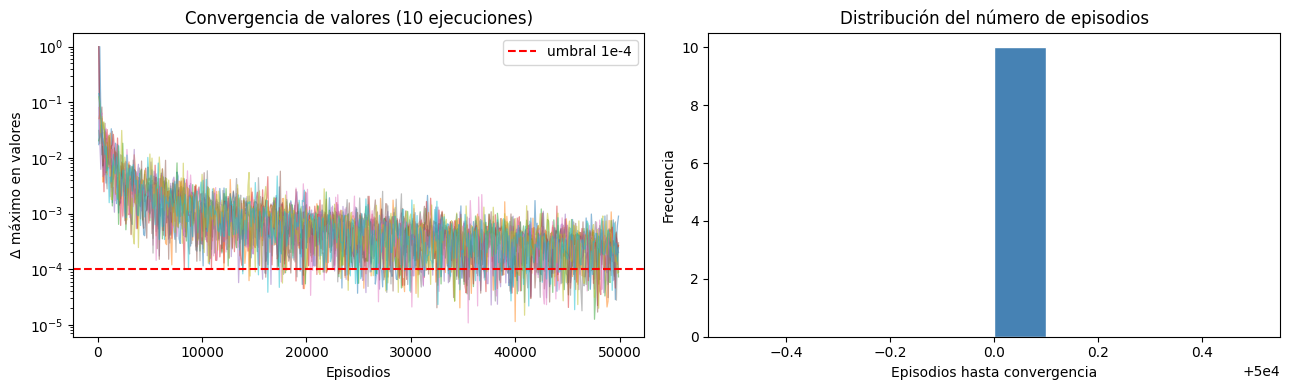

In [ ]:
NUM_RUNS = 10
episodes_list = []
sem_curves = []   # error estándar de la media a lo largo del tiempo

print("Ejecutando MCM 10 veces para analizar convergencia...\n")

for run in range(NUM_RUNS):
    np.random.seed(run * 42)
    agent = MCM(gridworld, discount=0.9, epsilon=0.1, noise=0.25,
                convergence_threshold=0.01, patience=3, window=100)
    agent.run_monte_carlo()
    episodes_list.append(agent.episodes_run)

    sem_by_window = []
    for snapshot_idx in range(len(agent.value_history)):
        ep_so_far = (snapshot_idx + 1) * 100
        max_sem = max(
            (np.std(agent.returns[s]) / (len(agent.returns[s]) ** 0.5))
            if len(agent.returns.get(s, [])) > 1 else 1.0
            for s in agent.returns
        )
        sem_by_window.append((ep_so_far, max_sem))
    sem_curves.append(sem_by_window)

    print(f"Run {run+1:2d}: {agent.episodes_run:5d} episodios")

print(f"\nEpisodios promedio: {np.mean(episodes_list):.0f} ± {np.std(episodes_list):.0f}")
print(f"Rango: [{min(episodes_list)}, {max(episodes_list)}]")

# --- Gráfica: curvas de convergencia ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for curve in sem_curves:
    xs = [p[0] for p in curve]
    ys = [p[1] for p in curve]
    axes[0].plot(xs, ys, alpha=0.5, linewidth=0.9)

axes[0].axhline(0.01, color='red', linestyle='--', label='umbral SEM = 0.01')
axes[0].set_xlabel("Episodios")
axes[0].set_ylabel("Error estándar de la media (máx)")
axes[0].set_title("Convergencia adaptativa (10 ejecuciones)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(episodes_list, bins=10, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Episodios hasta convergencia")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución del número de episodios")

plt.tight_layout()
plt.show()

La gráfica muestra que el cambio máximo en los valores decrece (con ruido) hasta cruzar el umbral `1e-4` que es nuestro umbral de convergencia. El número de episodios varía entre ejecuciones debido a la naturaleza estocástica del método, pero se estabiliza en un rango consistente (20000 y 50000 episodios para este Gridworld pequeño).

**Conclusión:** No existe un número "correcto" y fijo de muestras; el agente necesita tantas como sean necesarias para que sus estimaciones dejen de cambiar de forma significativa. El criterio adaptativo permite al agente detenerse antes en problemas fáciles y ejecutar más episodios en problemas difíciles, sin necesidad de hiperparámetros específicos al problema.


## 2. Comparación de valores MCM vs. Value Iteration

Se comparan los valores de los estados obtenidos por MCM con los obtenidos
por Value Iteration (50 iteraciones, γ=0.9). Se muestran los mapas de calor
y la diferencia estado por estado.


In [ ]:
mcm_values_runs = []
for seed in range(10):
    np.random.seed(seed)
    agent = MCM(gridworld, discount=0.9, epsilon=0.1, noise=0.25,
                convergence_threshold=0.01, patience=3, window=100)
    agent.run_monte_carlo()
    mcm_values_runs.append(agent.values)

print(f"Episodios promedio MCM: {np.mean([a.episodes_run for a in [agent]]):.0f}")


avg_mcm_values = {}
all_states = list(mcm_values_runs[0].keys())
for state in all_states:
    avg_mcm_values[state] = np.mean([r[state] for r in mcm_values_runs])

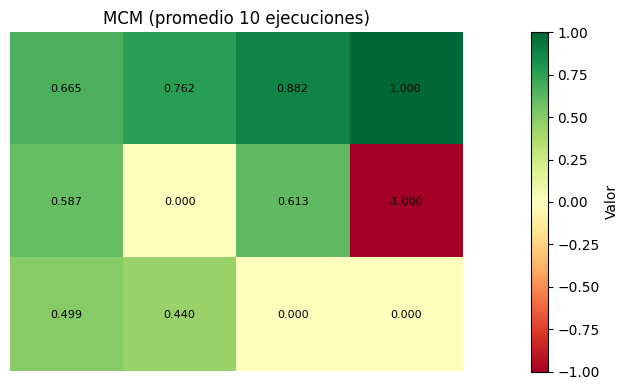

In [11]:
mcm_mat = values_to_matrix(avg_mcm_values, gridworld)

fig, axes = plt.subplots(1,1, figsize=(14, 4))
create_heatmap(mcm_mat, "MCM (promedio 10 ejecuciones)",axes)
plt.colorbar(axes.images[0], ax=axes, label="Valor")
plt.tight_layout()
plt.show()

*Resultado del gridworld en Value Iteration*

![Value Iteration en Gridworld](imgs/value.png)

Los mapas de calor muestran patrones muy similares: ambos métodos asignan
valores más altos a los estados cercanos al estado terminal `+1` y valores
bajos (o negativos) cerca del estado `-1`.

No obstante, si se encuentra una diferencia notoria en los valores, que dependen de que tan cerca están del estado terminal. En general, los valores del MCM son mayores que los del Value Iteration, lo que se refleja en la diferencia positiva en la mayoría de los estados.

También esto depende de donde explora el agente, porque en las esquinas inferiores derecha en nuestro caso, el agente no explora tanto, por lo que los valores son más bajos que los del Value Iteration. En cambio, en la parte superior izquierda, el agente explora más y obtiene valores más altos que el Value Iteration.

**¿Por qué existe esta diferencia?**

Los métodos de monte carlo son métodos de estimación basados en muestras, lo que introduce varias fuentes de variabilidad y diferencias respecto a los métodos basados en modelos como Value Iteration, que resuelven exactamente las ecuaciones de Bellman. Además, trae consigo otros factores como la política de exploración (ε-greedy) y el ruido que ocurre en el muestreo.

En resumen, la diferencia existe pero es pequeña, lo que confirma que MCM
converge a una solución cercana a la óptima sin necesitar el modelo.

## 3. Comparación de política MCM vs. Policy Iteration

Se compara la política greedy extraída de MCM con la política obtenida por
Policy Iteration (con las mismas configuraciones: γ=0.9).


In [13]:
np.random.seed(0)
mcm_agent = MCM(gridworld, discount=0.9, epsilon=0.1, noise=0.25,
                convergence_threshold=0.01, patience=3, window=100)
mcm_agent.run_monte_carlo()
print(f"MCM convergió en {mcm_agent.episodes_run} episodios")

MCM convergió en 20000 episodios

MCM:
  →  →  →  ✓
  ↑  █  ↑  ✓
  ↑  ←  ↑  ↓


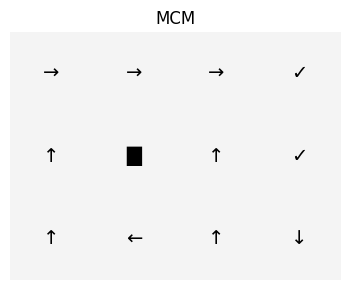

In [14]:
mcm_pol = policy_to_matrix(mcm_agent.get_policy, gridworld)

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for ax, mat, title in zip([axes],
                           [mcm_pol],
                           ["MCM"]):
    dummy = np.ones((gridworld.nrows, gridworld.ncols))
    ax.imshow(dummy, cmap="Greys", vmin=0, vmax=2, alpha=0.1)
    for i in range(gridworld.nrows):
        for j in range(gridworld.ncols):
            ax.text(j, i, mat[i, j], ha="center", va="center", fontsize=14)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

*Resultado del gridworld en Value Iteration*

![Value Iteration en Gridworld](imgs/policy.png)

En la mayoría de los estados las políticas **coinciden**. Ambas señalan hacia
el estado `+1` evitando el estado `-1`, lo que confirma que MCM aprende una
política muy cercana a la óptima.

No obstante, vuelve y ocurre el fenómeno de Value Iteration que es que en la esquina inferior derecha, el agente no explora tanto, por lo que la política de MCM es diferente a la de Policy Iteration para esas celdas. En cambio, en la parte superior izquierda, el agente explora más y obtiene la misma política que Policy Iteration.

**¿Por qué pueden existir diferencias en algunos estados?**

A diferencia de Value Iteration que sí tenía cambios grandes en sus valores, aquí como la política está limitada a las acciones disponibles, es más difícil que existan diferencias. Sin embargo, pueden existir diferencias en estados poco visitados como sucedió en este caso. No obstante, estas diferencias se reducen a medida que el agente explora más y obtiene mejores estimaciones de los valores.

## 4. Efecto del factor de descuento en MCM

Se ejecuta MCM con γ ∈ {0.1, 0.3, 0.5, 0.7, 0.9} y se muestran:
- El mapa de calor de valores.
- La política resultante.
- El número de episodios hasta convergencia.


 Descuento |  Episodios |   Val máximo |   Val mínimo
----------------------------------------------------
       0.1 |      20000 |       1.0000 |      -1.0000
       0.3 |      20000 |       1.0000 |      -1.0000
       0.5 |      20000 |       1.0000 |      -1.0000
       0.7 |      20000 |       1.0000 |      -1.0000
       0.9 |      20000 |       1.0000 |      -1.0000


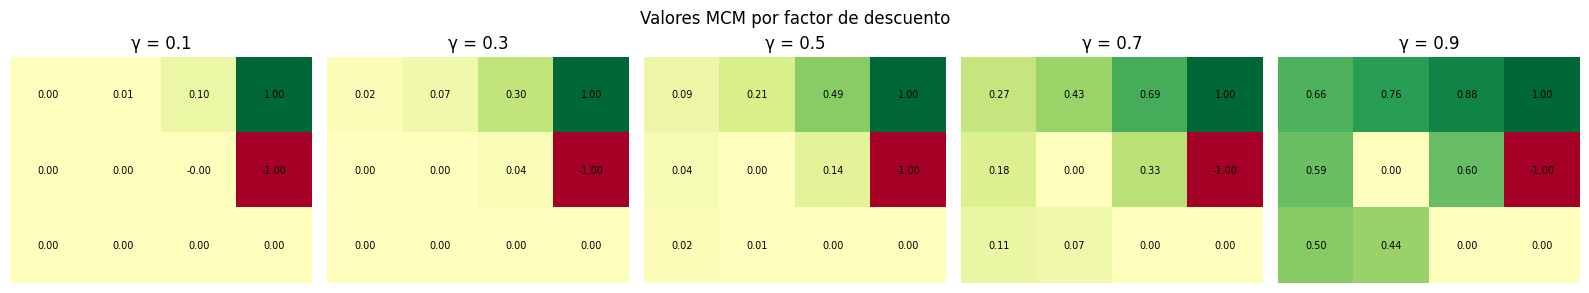

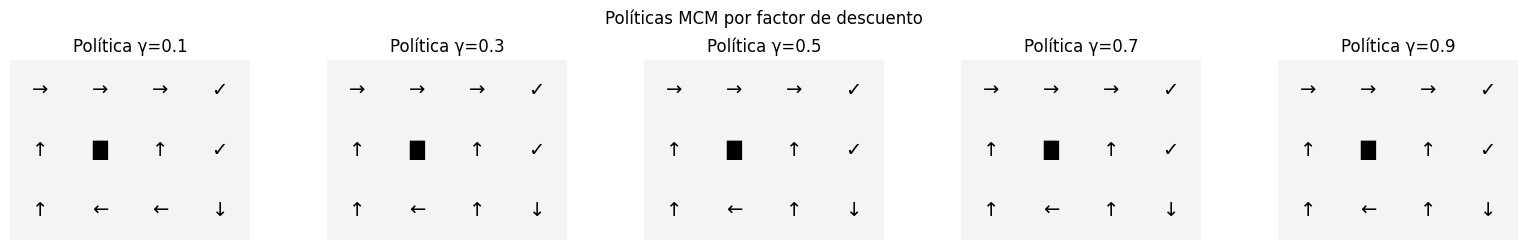

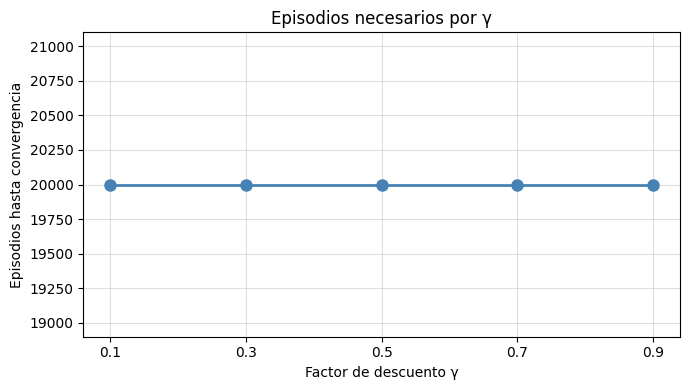

In [18]:
discounts = [0.1, 0.3, 0.5, 0.7, 0.9]
results_q4 = {}

print(f"{'Descuento':>10} | {'Episodios':>10} | {'Val máximo':>12} | {'Val mínimo':>12}")
print("-" * 52)

for g in discounts:
    np.random.seed(7)
    agent = MCM(gridworld, discount=g, epsilon=0.1, noise=0.25,
                convergence_threshold=0.01, patience=3, window=100)
    agent.run_monte_carlo()
    results_q4[g] = agent
    mat = values_to_matrix(agent.values, gridworld)
    print(f"{g:>10.1f} | {agent.episodes_run:>10d} | {mat.max():>12.4f} | {mat.min():>12.4f}")


fig, axes = plt.subplots(1, len(discounts), figsize=(16, 3))
for ax, g in zip(axes, discounts):
    mat = values_to_matrix(results_q4[g].values, gridworld)
    vmax = max(abs(mat.max()), abs(mat.min()))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=-vmax, vmax=vmax)
    ax.axis("off")
    for x in range(gridworld.nrows):
        for y in range(gridworld.ncols):
            ax.text(y, x, f"{mat[x,y]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"γ = {g}")
plt.suptitle("Valores MCM por factor de descuento")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(discounts), figsize=(16, 2.5))
for ax, g in zip(axes, discounts):
    pol = policy_to_matrix(results_q4[g].get_policy, gridworld)
    ax.imshow(np.ones((gridworld.nrows, gridworld.ncols)), cmap="Greys", vmin=0, vmax=2, alpha=0.1)
    for i in range(gridworld.nrows):
        for j in range(gridworld.ncols):
            ax.text(j, i, pol[i, j], ha="center", va="center", fontsize=14)
    ax.set_title(f"Política γ={g}")
    ax.axis("off")
plt.suptitle("Políticas MCM por factor de descuento")
plt.tight_layout()
plt.show()


ep_por_gamma = [results_q4[g].episodes_run for g in discounts]
plt.figure(figsize=(7, 4))
plt.plot(discounts, ep_por_gamma, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel("Factor de descuento γ")
plt.ylabel("Episodios hasta convergencia")
plt.title("Episodios necesarios por γ")
plt.xticks(discounts)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


El factor de descuento γ controla cuánto valora el agente las recompensas
futuras en relación con las inmediatas. Sus efectos en MCM son:

| γ bajo (≈ 0.1) | γ alto (≈ 0.9) |
|---|---|
| El agente valora sólo recompensas muy inmediatas | El agente considera recompensas lejanas |
| Los valores decaen rápidamente con la distancia al terminal | Los valores se propagan ampliamente por el tablero |
| Converge más rápido (retornos pequeños, menos varianza) | Puede requerir más episodios (retornos grandes y variables) |
| Política puede volverse subóptima en estados lejanos | Política óptima más robusta para todo el tablero |